   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 89.2 MB/s eta 0:00:00:00:0100:01


In [5]:
import zipfile
import os

zip_path = "dataset/Archive.zip"
extract_to_dir = "dataset/unzipped/"

os.makedirs(extract_to_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(path=extract_to_dir)

print(f"Extracted all files to {extract_to_dir}")


Extracted all files to dataset/unzipped/


In [1]:
import torch
import cv2

In [1]:
# !pip install -r dataset/PHLOP/requirements.txt

In [2]:
!pip install transformers
%pip install einops timm
%pip install opencv-python

!pip install flash-attention
!pip install sentencepiece
%pip install decord
%pip install einops

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 33.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 18.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.9/796.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 21.8 MB/s eta 0:00:00a 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user install

In [1]:
import torch
print("CUDA available? ", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device name:", torch.cuda.get_device_name(0))


CUDA available?  True
CUDA device count: 1
Current device name: Tesla V100-PCIE-16GB


In [1]:

from transformers import AutoTokenizer, AutoModel
import torch

model_path = "OpenGVLab/InternVideo2_5_Chat_8B"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)


# model = AutoModel.from_pretrained("OpenGVLab/InternVideo2_5_Chat_8B", trust_remote_code=True)
model = AutoModel.from_pretrained(
    "OpenGVLab/InternVideo2_5_Chat_8B",
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.float16
)

/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by lo

FlashAttention2 is not installed.


/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/accelerate/utils/modeling.py:1569: UserWarning: Current model requires 67109376 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 4/4 [00:34<00:00,  8.70s/it]
Some parameters are on the meta device because they were offloaded to the cpu.


In [1]:
#torch.cuda.is_available()
!nvidia-smi

Fri Jun  6 17:59:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.10              Driver Version: 570.86.10      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-16GB           On  |   00000000:58:00.0 Off |                    0 |
| N/A   35C    P0             26W /  250W |     104MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
model.eval()

InternVLChatModel(
  (vision_model): InternVisionModel(
    (embeddings): InternVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): InternVisionEncoder(
      (layers): ModuleList(
        (0-23): 24 x InternVisionEncoderLayer(
          (attn): InternAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): InternMLP(
            (act): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (drop_path1): Ide

In [6]:
# print(model.device)
path = "/data/scratch/eez086/phlop/data"
json_path = f"{path}/3/obj.json"
video_path = f"{path}/3/output_video.mp4"

# json_path = "dataset/unzipped/3/obj.json"
# video_path = "dataset/unzipped/3/output_video.mp4"

In [7]:
import json
# json_path = "dataset/unzipped/3/obj.json"
# video_path = "dataset/unzipped/3/output_video.mp4"
data    = json.load(open(json_path))
frames  = data["frames"]

fps = 25

for f in frames:
    if f["interactions"]:  
        t = f["time"]          
        pairs = f["interactions"]
        break
else:
    t, pairs = None, []

print("Collision?", "Yes" if pairs else "No")
print("Time (s):", t)
print("Pairs:", pairs)


Collision? Yes
Time (s): 0.0005
Pairs: [[3, 5]]


In [28]:
import cv2
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode


In [12]:
from decord import VideoReader, cpu


def load_video_frames_opencv(path, expected_time=None, fps=25, num_segments=32, input_size=448):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if expected_time is not None:
        # Sample more densely around expected collision time
        collision_frame = int(expected_time * fps)
        start = max(0, collision_frame - 16)
        end = min(total_frames, collision_frame + 16)
        idxs = list(range(start, end, 2))  # Sample every 2nd frame in this window
    else:
        # Default uniform sampling
        seg_size = max(total_frames // num_segments, 1)
        idxs = [i * seg_size for i in range(num_segments)]
    
    transform = build_transform(input_size)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frames.append(transform(img).unsqueeze(0))
    
    cap.release()
    pixel_values = torch.cat(frames, dim=0) if frames else torch.zeros(1, 3, input_size, input_size)
    num_patches = [1] * pixel_values.shape[0]
    return pixel_values, num_patches


# image preprocess
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
# ImageNet stats 

def build_transform(size):
    return T.Compose([
        T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
        T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [13]:
prompt = """
 Analyze the given video to demonstrate causal reasoning about object interactions and motion dynamics. 
 Focus on explaining how physical properties and taxonomy labels relate to observed behaviors.

Instructions:
- examine how each object's mass, density, elasticity, and friction coefficients influence their motion patterns
- explain how the floor's friction properties affect object deceleration
- create event chains showing how:
    ** Initial velocities + angular velocities → Resulting trajectories
    ** Material properties → Collision outcomes
    ** Environmental factors → Motion changes

Output Format:
 - Physical analysis with quantitative comparisons
 - Timeline of predicted events with confidence estimates
 - Visualized causal graphs showing property-behavior relationships
 - Uncertainty estimates for predictions based on parameter sensitivity

Evaluation Criteria:
 - Accuracy in applying physics principles
 - Logical consistency between properties and labels
 - Predictive validity of causal models
 - Appropriate handling of parameter uncertainties
"""

In [14]:

pixel_values, num_patches = load_video_frames_opencv(video_path)
dtype = next(model.parameters()).dtype
print(dtype)
pixel_values = pixel_values.to(model.device, dtype=dtype)


video_prefix = "".join(f"Frame{i+1}: <image>\n" for i in range(len(num_patches)))
# question = (
#         video_prefix +
#         # "Did a collision occur between any objects in this video? "
#         # "Answer only “Yes” or “No.”"
#         "Did a collision occur between any objects in this video? "
#         "If yes, answer exactly “Yes, Frame <n>”. "
#         "If no, answer exactly “No”."

# )
question = (
    video_prefix +
    prompt
    # "Did any object experience an elastic collision?"
   # "Analyze the video carefully. Did any physical collision occur between objects? "
   # "Describe what happens in the video, paying attention to object interactions. "
   # "If you see objects making contact and changing motion, mention this explicitly."
)

gen_cfg = {
        "do_sample": False,
        "temperature": 0.1,
        "max_new_tokens": 255,
        "top_p": 1.0,
        "num_beams": 1,
}

with torch.no_grad():
    answer, h = model.chat(
        tokenizer,
        pixel_values.to(model.device),
        question,
        gen_cfg,
        num_patches_list=num_patches,
        history=None,
        return_history=True
    )
    print(h)
    print(answer)

NameError: name 'video_path' is not defined

In [15]:
answer

NameError: name 'answer' is not defined

In [ ]:
print(answer)

In [1]:
from data_load import PHOLPhysicsDataset
from torch.utils.data import Dataset, DataLoader

video_tf = lambda x: x
mask_tf  = lambda x: x[:1]
def collate_fn(batch):
    return batch

In [2]:
root = "/data/scratch/eez086/phlop/data/"
# ds = PHOLPhysicsDataset(root, video_transform=video_tf, mask_transform=mask_tf)
ds = PHOLPhysicsDataset(root, include_qa=True)
loader = DataLoader(ds, 
                    batch_size=1, 
                    shuffle=False,
                    collate_fn=collate_fn 
                   )

all_dirs 4000
valid 4000
numeric 4000
non_numeric 0
 self.scenes  4000 0


In [3]:
b = next(iter(loader))


transitions {'stopped_objects': {'geom_obj0'}, 'moving_to_stationary': {'geom_obj0'}, 'stationary_to_moving': set(), 'rolling': {'geom_obj4', 'geom_obj2', 'geom_obj1'}}
defaultdict(<class 'int'>, {'geom_obj1': 1, 'geom_obj2': 1})
collision_pairs  [('geom_obj1', 'geom_obj2')]
_get_kinematic_loss collision_pairs [('geom_obj1', 'geom_obj2')]


In [32]:
len(b[0]["taxonomy"]["geom_obj0"])

376

In [33]:
b[0].keys()

dict_keys(['scene_id', 'video', 'segmentation', 'physical_props', 'has_collisions', 'taxonomy', 'annotations', 'qa'])

In [34]:
b[0]["physical_props"]

{'geom_obj0': {'mass': 1.7788129482860462,
  'friction': [0.87, 1.04, 0.9],
  'elasticity': 0.953,
  'velocity': [-2.7718996217032537, 1.1713590103736033, -0.04688883119852405],
  'position': [1.409590004512614, -0.5956694606797639, 0],
  'material': 'rubber',
  'shape': 'cylinder',
  'color': 'goldenrod'},
 'geom_obj2': {'mass': 3.6195545071418334,
  'friction': [0.44, 0.36, 0.42],
  'elasticity': 0.758,
  'velocity': [-2.325489174979635, 0.39119075806195214, 0.08233036340813249],
  'position': [1.4521873368889726, -0.24428506108635814, 0],
  'material': 'plastic',
  'shape': 'sphere',
  'color': 'hotpink'},
 'geom_obj4': {'mass': 1.9820322160386172,
  'friction': [0.83, 0.9, 0.86],
  'elasticity': 0.918,
  'velocity': [0.8890661339326864, -0.9539508706265446, 0.020308461983990764],
  'position': [0.24777392943277848, -1.692353072326412, 0],
  'material': 'rubber',
  'shape': 'sphere',
  'color': 'gold'},
 'geom_obj3': {'mass': 0.731360658410741,
  'friction': [0.17, 0.16, 0.23],
  'e

In [37]:
b[0]["qa"]

[{'question': 'Do any objects collide in this scene?', 'answer': 'Yes'},
 {'question': 'How many objects are in this scene?', 'answer': '5'},
 {'question': 'How many objects have stopped in the video?', 'answer': '1'},
 {'question': 'How many objects changing state from moving towards stationary (deacelerating) state during the video?',
  'answer': '5'},
 {'question': 'How many objects go from stationary to moving state in the video?',
  'answer': '0'},
 {'question': 'How many objects were involved in collisions?', 'answer': '2'},
 {'question': 'Which object collided with the most other objects?',
  'answer': 'darkcyan sphere made of metal'},
 {'question': 'How many differen collitions have happened in the video?',
  'answer': '1'},
 {'question': 'What is total kinetic energy loss of the system when darkcyan sphere made of metal collides with hotpink sphere made of plastic?',
  'answer': '2.7%',
  'details': {'system_loss': '2.7%',
   'geom_obj1_loss': '2.2%',
   'geom_obj2_loss': '5.8

In [2]:

from transformers import AutoTokenizer, AutoModel
import torch

model_path = "OpenGVLab/InternVideo2_5_Chat_8B"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)


# model = AutoModel.from_pretrained("OpenGVLab/InternVideo2_5_Chat_8B", trust_remote_code=True)
model = AutoModel.from_pretrained(
    "OpenGVLab/InternVideo2_5_Chat_8B",
    trust_remote_code=True,
    device_map="auto",
    torch_dtype=torch.float16
)

# model_name = "OpenGVLab/InternVideo2_5_Chat_8B"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")


/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by lo

FlashAttention2 is not installed.


/data/home/eez086/.conda/envs/llama-gpu/lib/python3.10/site-packages/accelerate/utils/modeling.py:1569: UserWarning: Current model requires 67109376 bytes of buffer for offloaded layers, which seems does not fit any GPU's remaining memory. If you are experiencing a OOM later, please consider using offload_buffers=True.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 4/4 [00:35<00:00,  8.77s/it]
Some parameters are on the meta device because they were offloaded to the cpu.


In [3]:
model.eval()

InternVLChatModel(
  (vision_model): InternVisionModel(
    (embeddings): InternVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    )
    (encoder): InternVisionEncoder(
      (layers): ModuleList(
        (0-23): 24 x InternVisionEncoderLayer(
          (attn): InternAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (mlp): InternMLP(
            (act): GELUActivation()
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (drop_path1): Ide

In [4]:
from torch.utils.data import Dataset, DataLoader
from data_load import PHOLPhysicsDataset

root = "/data/scratch/eez086/phlop/data/"

def collate_fn(batch):
    return {
        'scene_id': [item['scene_id'] for item in batch],
        'video': torch.stack([item['video'] for item in batch]),
        'qa': [item['qa'] for item in batch],
        'physical_props': [item['physical_props'] for item in batch],
        'taxonomy': [item['taxonomy'] for item in batch]
    }

dataset = PHOLPhysicsDataset(root=root, include_qa=True)
dataloader = DataLoader(dataset, 
                        batch_size=1, 
                        shuffle=True, 
                        collate_fn=collate_fn)




all_dirs 4000
valid 4000
numeric 4000
non_numeric 0
 self.scenes  4000 0


In [5]:
from decord import VideoReader, cpu
# AGENET_MEAN = (0.485, 0.456, 0.406)
# IMAGENET_STD  = (0.229, 0.224, 0.225)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_transform(size):
    return T.Compose([
        T.Lambda(lambda img: img.convert("RGB") if img.mode != "RGB" else img),
        T.Resize((size, size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def load_video_frames_opencv(path, expected_time=None, fps=25, num_segments=32, input_size=448):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    seg_size = max(total_frames // num_segments, 1)
    idxs = [i * seg_size for i in range(num_segments)]
    
    transform = build_transform(input_size)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_idx)
        ret, frame = cap.read()
        if not ret:
            continue
        img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        frames.append(transform(img).unsqueeze(0))
    
    cap.release()
    pixel_values = torch.cat(frames, dim=0) if frames else torch.zeros(1, 3, input_size, input_size)
    num_patches = [1] * pixel_values.shape[0]
    return pixel_values, num_patches


def assess_response(prediction, ground_truth):
    # assessment with keyword matching and numeric comparison
    # numeric
    if any(word in ground_truth.lower() for word in ["mass", "friction", "velocity"]):
        try:
            gt_num = float(''.join(c for c in ground_truth if c.isdigit() or c == '.'))
            pred_num = float(''.join(c for c in prediction if c.isdigit() or c == '.'))
            return 1.0 if abs(gt_num - pred_num) < 0.1 else 0.0
        except:
            return 0.0
    
    # qualitative questions
    keywords = {
        "collision": ["collide", "impact", "hit"],
        "material": ["made of", "material", "composition"],
        "motion": ["moving", "sliding", "rolling"]
    }
    
    score = 0
    for category, terms in keywords.items():
        if any(term in ground_truth.lower() for term in terms):
            if any(term in prediction.lower() for term in terms):
                score += 1
    return score / len(keywords)

In [6]:
# import numpy as np
# from tqdm import tqdm
# import os
# import cv2

# max_samples = 15
# results = []
# sample_count = 0
# num_segments = 32

# torch.backends.cuda.enable_flash_sdp(True)
# torch.cuda.empty_cache()

# for batch in tqdm(dataloader):
#     if sample_count >= max_samples:
#         break

#     sample_count = 0
#     for i in range(len(batch['scene_id'])):
#         scene_id = batch['scene_id'][i]
#         video_path = os.path.join(root, scene_id, "simulation_objects.mp4")
#         video = batch['video'][i]  # Shape: (C, T, H, W)
#         # annotations = batch['annotations'][i]
#         qa_pairs = batch['qa'][i]

#         pixel_values, num_patches = load_video_frames_opencv(
#                     path=video_path,
#                     # expected_time=collision_time,
#                     num_segments=num_segments,
#                     input_size=224
#                 )

#         pixel_values = pixel_values.to(model.device, dtype=model.dtype)
                
#         video_prefix = "".join(f"Frame{i+1}: <image>\n" for i in range(len(num_patches)))

#         # Process each QA pair
#         for qa in qa_pairs:
#                 full_prompt = video_prefix + qa['question']
                
#                 # Generate response
#                 with torch.no_grad():
#                     response = model.chat(
#                         tokenizer=tokenizer,
#                         pixel_values=pixel_values,
#                         question=full_prompt,
#                         generation_config={
#                             "do_sample": False,
#                             "max_new_tokens": 100,
#                             "temperature": 0.1
#                         },
#                         num_patches_list=num_patches,
#                         history=None
#                     )
    
#                 correctness = assess_response(response, qa['answer'])
                
#                 results.append({
#                     "scene_id": batch['scene_id'][i],
#                     "question": qa['question'],
#                     "predicted": response,
#                     "ground_truth": qa['answer'],
#                     "correctness": correctness,
#                     "has_physics": "mass" in qa['question'] or "friction" in qa['question'],
#                     "has_taxonomy": any(t in qa['question'] for t in ["collide", "slide", "roll"])
#                 })
                
#                 sample_count += 1
#                 if sample_count >= max_samples:
#                     break
    
       

In [7]:
# def analyze_results(results):
#     if not results:
#         print("No results to analyze")
#         return
    
#     # Calculate overall accuracy
#     avg_accuracy = np.mean([r['correctness'] for r in results])
    
#     # Compare performance with/without physics
#     physics_qs = [r for r in results if r['has_physics']]
#     non_physics_qs = [r for r in results if not r['has_physics']]
    
#     print(f"\nOverall Accuracy: {avg_accuracy:.2%}")
#     if physics_qs:
#         print(f"Physics Questions Accuracy: {np.mean([r['correctness'] for r in physics_qs]):.2%}")
#     if non_physics_qs:
#         print(f"Non-Physics Questions Accuracy: {np.mean([r['correctness'] for r in non_physics_qs]):.2%}")
    
#     # Compare taxonomy vs non-taxonomy
#     taxonomy_qs = [r for r in results if r['has_taxonomy']]
#     non_taxonomy_qs = [r for r in results if not r['has_taxonomy']]
    
#     if taxonomy_qs:
#         print(f"\nTaxonomy Questions Accuracy: {np.mean([r['correctness'] for r in taxonomy_qs]):.2%}")
#     if non_taxonomy_qs:
#         print(f"Non-Taxonomy Questions Accuracy: {np.mean([r['correctness'] for r in non_taxonomy_qs]):.2%}")


# analyze_results(results)
    
#     # # Save results
#     # with open("evaluation_results.json", "w") as f:
#     #     json.dump(results, f, indent=2)



In [8]:
# results

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode


def show_video_frames(video_path, num_segments=32, n_cols=8, figsize=(16, 8)):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video at {video_path}")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        print(f"Warning: Video at {video_path} has zero frames.")
        cap.release()
        return

    # Choose `num_segments` evenly spaced indices between 0 and total_frames-1
    frame_indices = np.linspace(0, total_frames - 1, num_segments, dtype=int)

    # Read and store each selected frame (in RGB)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Could not read frame {idx}. Skipping.")
            continue
        # Convert BGR to RGB for display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append((idx, frame_rgb))

    cap.release()

    # Determine grid layout (n_rows computed automatically)
    n_rows = int(np.ceil(len(frames) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    plt.suptitle(f"Video frames (total={total_frames}) → showing {len(frames)} slices", fontsize=16)

    # Flatten axes so we can index them easily
    axes_flat = axes.flatten()

    for i, (frame_idx, frame_rgb) in enumerate(frames):
        ax = axes_flat[i]
        ax.imshow(frame_rgb)
        ax.set_title(f"Frame {frame_idx + 1}")
        ax.axis('off')

    # Turn off any unused subplots
    for j in range(len(frames), len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [17]:
from tqdm import tqdm
import cv2
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode


def build_dynamic_prompt(video_frames, taxonomy, physical_props, question):
    # group taxonomy labels by object and temporal phase
    object_behaviors = {}
    for obj_id, frame_labels in taxonomy.items():
        # Group labels by temporal phase (early/middle/late)
        phases = {
            'early': set(),
            'middle': set(),
            'late': set()
        }
        total_frames = len(frame_labels)
        for i, labels in enumerate(frame_labels):
            phase = 'early' if i < total_frames//3 else 'late' if i >= 2*total_frames//3 else 'middle'
            phases[phase].update(labels)
        
        # filter labels
        phases = {k: set([l for l in v if l]) for k,v in phases.items()}
        object_behaviors[obj_id] = phases

    # physics
    physics_context = []
    for obj_id, phases in object_behaviors.items():
        desc = f"{physical_props[obj_id]['color']} {physical_props[obj_id]['shape']}"
        phase_descs = []
        
        for phase in ['early', 'middle', 'late']:
            if phases[phase]:
                phase_descs.append(
                    f"{phase} phase: {', '.join(phases[phase])}"
                )
        
        if phase_descs:
            physics_context.append(
                f"{desc}: {'; '.join(phase_descs)}"
            )


    video_context = ''.join(f"Frame {i+1}: <image>\n" for i in range(len(video_frames)))
    
    if physics_context:
        physics_context_str = '\n'.join(physics_context)
    else:
        physics_context_str = 'No behavior labels available'
    # desc = f"{physical_props[obj_id]['color']} {physical_props[obj_id]['shape']}"
    physical_props_str = '\n'.join(
        f"{v['color']} {v['shape']}: mass={v['mass']}, friction={v['friction'][0]:.2f}"
        for k, v in physical_props.items()
    )

    print("physics_context_str", physics_context_str)
    
    # [OBJECT BEHAVIORS OVER TIME]
    # {physics_context_str}
    
    # prompt = f"""
    # [VIDEO CONTEXT]
    # You have a sequence of {len(video_frames)} frames representing a physical simulation. Below you’ll see placeholders for each frame:
    # {video_context}

    # [OBJECT BEHAVIORS OVER TIME]
    # {physics_context_str}
    
    # [PHYSICAL PROPERTIES]
    # {physical_props_str}
    
    # [QUESTION]
    # {question}
    
    # [INSTRUCTIONS]
    # 1. First, identify which frames or temporal phase(s) are most relevant.
    # 2. Reference any physics principles (e.g., momentum, friction, force) that explain what happens.
    # 3. Use the object properties (mass, friction) in your reasoning where appropriate.
    # 4. If the question asks for a number, provide a numeric answer (and include your units).
    # 5. If the question is yes/no, answer exactly “Yes.” or “No.” (with an optional brief justification).
    # 6. Summarize your final answer in a single line at the end.
    
    # [BEGIN ANSWER]
    # """

    # 2. OBJECT BEHAVIORS:
    # {physics_context_str}
    prompt = f"""
    [VIDEO ANALYSIS TASK]
You are a physics-aware video reasoning system analyzing a physical simulation with partial information (8% of frames available). Use the provided context to answer questions about the dynamics.

[CONTEXTUAL INFORMATION]
1. FRAME SEQUENCE: {len(video_frames)} frames ({video_context}) 

3. PHYSICAL PROPERTIES:
{physical_props_str}

[REASONING FRAMEWORK]
1. Temporal Mapping:
   - First identify which phase (early/middle/late) contains the most relevant frames
   - Consider behavior transitions between sampled frames

2. Physics Principles:
   - Motion: Analyze acceleration/deceleration patterns
   - Forces: Account for friction coefficients and contact forces
   - Energy: Consider kinetic/potential energy changes
   - Rotation: Distinguish rolling vs. sliding motions

3. Uncertainty Handling:
   - Explicitly note when frame sparsity creates ambiguity
   - Distinguish between observed behavior and likely interpolation
   - Use physical laws to fill information gaps

4. Object Interactions:
   - Track relative positions in sampled frames
   - Infer collision dynamics from pre/post states

[QUESTION]
{question}

[RESPONSE PROTOCOL]
1. Phase Identification: "Relevant phase(s): [X] because [justification]"
2. Physics Analysis: "Governing principles: [X] due to [observed behavior]"
3. Calculation (if needed): Show dimensional analysis
4. Confidence Assessment: "Certainty: High/Medium/Low because [reason]"
5. Final Answer: 
   - For quantitative: "[Value] [Units] (from [calculation method])"
   - For qualitative: "[Answer]. [1-sentence explanation]"
   - For yes/no: "[Yes/No]. [<5 word reason]"

[EXAMPLE RESPONSE STRUCTURE]
Relevant phase(s): early phase (frames 2-4 show transition from sliding to rolling)
Governing principles: μ_k > μ_s explains deceleration pattern
Certainty: Medium (missing frames between 4-7)
Final Answer: 0.45 m/s² (calculated from Δv/Δt across 3 frames)

[BEGIN ANALYSIS]
    """

    # prompt = f"""
    # [Video Context]:
    # {video_context}
    
    # [Physics Context]:
    # {physics_context_str}
    
    # Physical Properties:
    # {physical_props_str}
    
    # Question: {question}

    # instructions: make sure the answer is a number if the questions asks for a number, or yes/no.
    # """
    return prompt.strip()



    
def evaluate_with_dynamic_taxonomy(dataloader, model, tokenizer, root, max_samples=5):
    results = []
    count = 0 
    for batch in tqdm(dataloader):
        batch = dataset[2829]
        if count >= max_samples:
            break
        count += 1
        
        scene_id = batch['scene_id']
        # scene_id = batch['scene_id'][0]
        
        video_path = f"{root}/{scene_id}/simulation_objects.mp4"
        show_video_frames(video_path, num_segments=32)

        # Load frames and ensure they're on the correct device
        pixel_values, num_patches = load_video_frames_opencv(
            video_path, num_segments=32, input_size=224
        )
        pixel_values = pixel_values.to(model.device, dtype=model.dtype)
        
        # Ensure num_patches is on the correct device if it's a tensor
        if isinstance(num_patches, torch.Tensor):
            num_patches = num_patches.to(model.device)

        # taxonomy = batch['taxonomy'][0]
        # physical_props = batch['physical_props'][0]
        # qa_pairs = batch['qa'][0]
        taxonomy = batch['taxonomy']
        physical_props = batch['physical_props']
        qa_pairs = batch['qa']
        
        for qa in qa_pairs:
            prompt = build_dynamic_prompt(
                video_frames=range(len(num_patches)),
                taxonomy=taxonomy,
                physical_props=physical_props,
                question=qa['question']
            )
            
            # print(prompt)
            
            try:
                with torch.no_grad():
                    response = model.chat(
                        tokenizer=tokenizer,
                        pixel_values=pixel_values,
                        question=prompt,
                        generation_config={
                            "do_sample": False,
                            "max_new_tokens": 200,
                            "temperature": 0.1
                        },
                        num_patches_list=num_patches,
                        history=None
                    )
            except RuntimeError as e:
                print(f"Error during generation: {e}")
                response = "Error in generating response"

            score = evaluate_response_quality(
                response,
                qa['answer'],
                taxonomy,
                physical_props
            )

            print("Question:", qa['question'])
            print("Model response:", response)
            print("True answer:", qa["answer"])
            print("Scene ID:", scene_id)
            print("-" * 80)
            
            results.append({
                "scene_id": scene_id,
                "question": qa['question'],
                "answer": qa["answer"],
                "response": response,
                "accuracy": score['accuracy'],
                "physics_score": score['physics'],
                "temporal_score": score['temporal'],
                "property_usage": score['properties']
            })
        break
    return results
    
def evaluate_response_quality(response, ground_truth, taxonomy, physical_props):
    """Multi-dimensional evaluation of response quality"""
    
    scores = {
        'accuracy': 0,
        'physics': 0,
        'temporal': 0,
        'properties': 0
    }
    
    # 1. Basic accuracy
    scores['accuracy'] = assess_response(response, ground_truth)
    
    # 2. Physics principles used
    physics_terms = ["momentum", "force", "friction", "energy", "velocity"]
    scores['physics'] = min(1.0, sum(term in response.lower() for term in physics_terms)/3)
    
    # 3. Temporal awareness
    time_terms = ["initially", "then", "finally", "after", "before"]
    scores['temporal'] = 0.5 if any(term in response.lower() for term in time_terms) else 0
    
    # 4. Property usage
    prop_count = 0
    for obj_id, props in physical_props.items():
        if str(props['mass']) in response or str(props['friction'][0]) in response:
            prop_count += 1
    scores['properties'] = min(1.0, prop_count/len(physical_props))
    
    return scores

  0%|          | 0/4000 [00:00<?, ?it/s]

transitions {'stopped_objects': {'geom_obj2'}, 'moving_to_stationary': {'geom_obj2'}, 'stationary_to_moving': set(), 'rolling': {'geom_obj0', 'geom_obj1', 'geom_obj3'}}
transitions {'stopped_objects': {'geom_obj3'}, 'moving_to_stationary': {'geom_obj3'}, 'stationary_to_moving': set(), 'rolling': {'geom_obj2', 'geom_obj1'}}


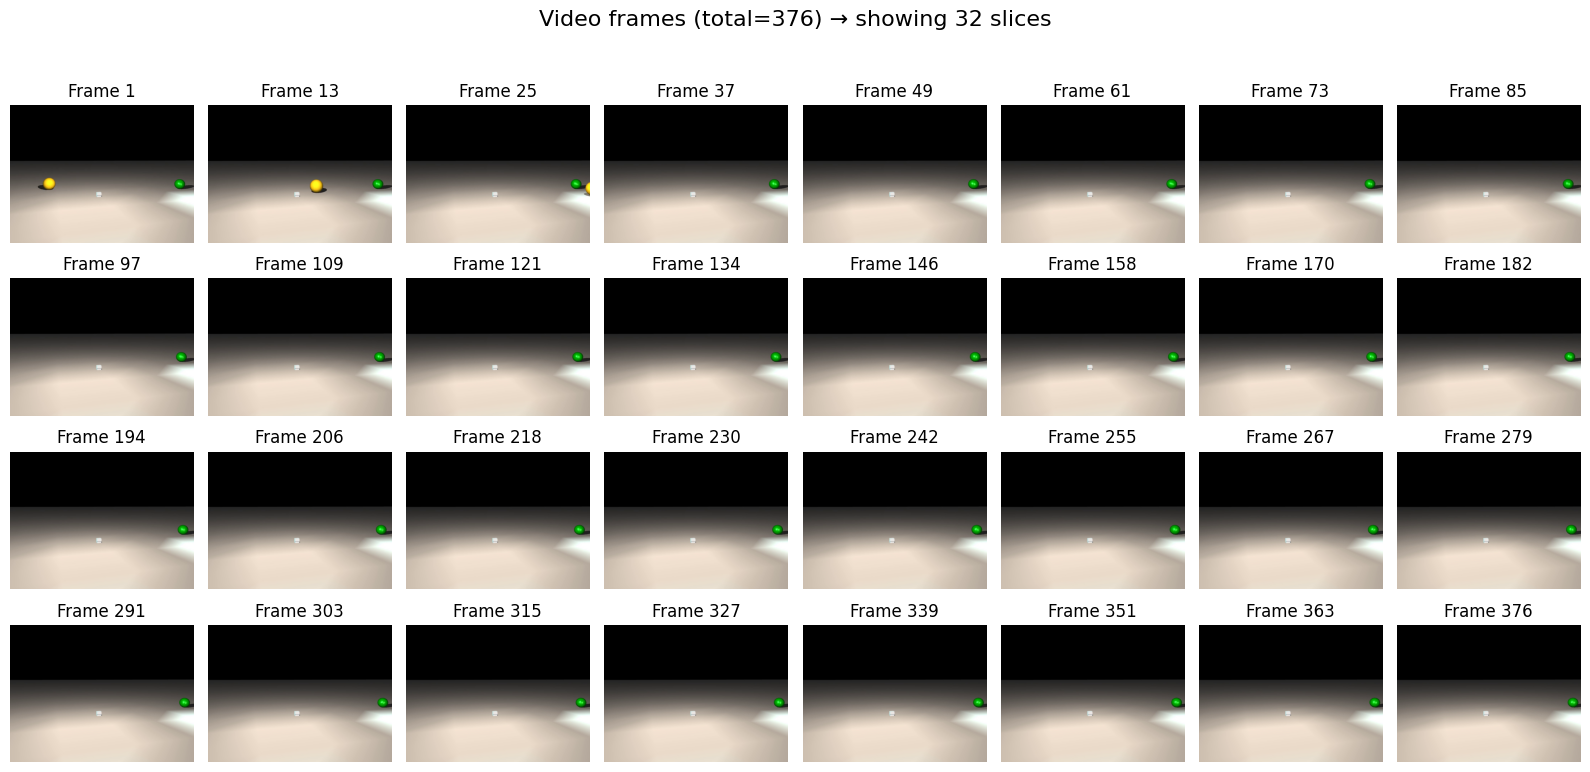

physics_context_str gold sphere: early phase: Sliding with Friction, Rolling Motion with Slipping, Accelerating, Moving to Stopping, Decelerating, Rolling Motion; middle phase: Moving to Stopping, Constant Velocity, Decelerating, Rolling Motion; late phase: Constant Velocity, Rolling Motion
mediumturquoise box: early phase: Friction Stop, Accelerating, Moving to Stopping, Stationary, Decelerating; middle phase: Stationary, Friction Stop; late phase: Stationary, Friction Stop
green sphere: early phase: Rolling Motion with Slipping, Constant Velocity, Accelerating, Moving to Stopping, Decelerating, Rolling Motion; middle phase: Constant Velocity, Rolling Motion; late phase: Constant Velocity, Rolling Motion
Question: Does the video show any instances where two or more objects make physical contact or collide with each other?
Model response: Relevant phase(s): early phase (frames 1-2 show transition from sliding to rolling)
Governing principles: Friction explains deceleration pattern
Cert

  0%|          | 0/4000 [05:31<?, ?it/s]

Question: What is the total number of separate collision events that occurred between different object pairs in the video?
Model response: Relevant phase(s): early phase (frames 1-2 show transition from sliding to rolling)
Governing principles: Friction and rolling motion explain the deceleration pattern
Certainty: Medium (frame sparsity creates ambiguity in the middle phase)
Final Answer: 0.
True answer: 0
Scene ID: 2829
--------------------------------------------------------------------------------


In [15]:

torch.backends.cuda.enable_flash_sdp(True)
torch.cuda.empty_cache()
# root = "/data/scratch/eez086/phlop/data/"

# compare performance with/without taxonomy:
# baseline_acc = evaluate_vanilla_model()
enhanced_acc = evaluate_with_dynamic_taxonomy(dataloader, model, tokenizer, root, max_samples=5)
# improvement = (enhanced_acc - baseline_acc) / baseline_acc



  0%|          | 0/4000 [00:00<?, ?it/s]

transitions {'stopped_objects': {'geom_obj0', 'geom_obj2', 'geom_obj5'}, 'moving_to_stationary': {'geom_obj0', 'geom_obj2', 'geom_obj5'}, 'stationary_to_moving': set(), 'rolling': {'geom_obj1', 'geom_obj3'}}
transitions {'stopped_objects': {'geom_obj3'}, 'moving_to_stationary': {'geom_obj3'}, 'stationary_to_moving': set(), 'rolling': {'geom_obj2', 'geom_obj1'}}


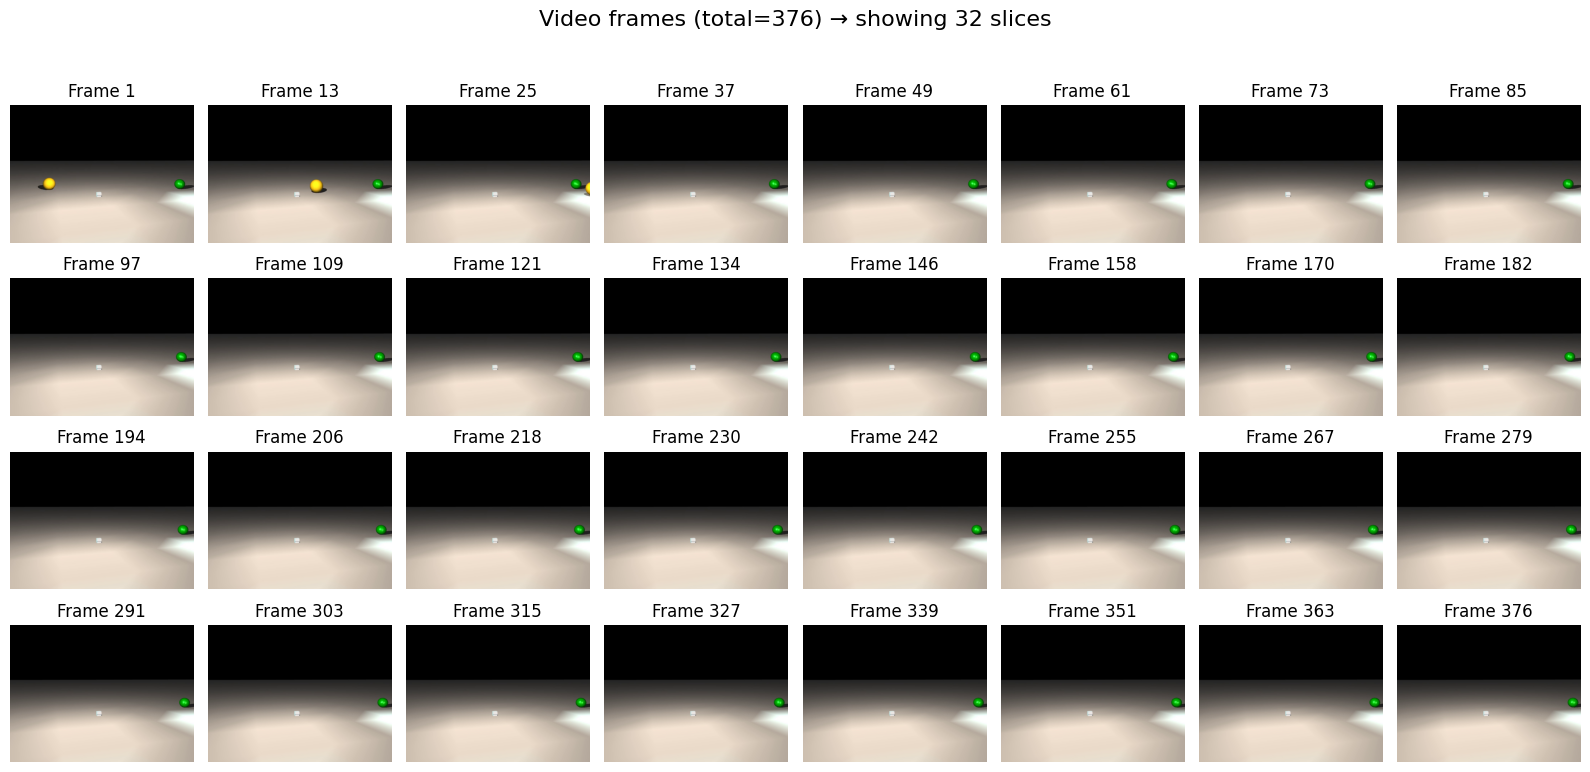

physics_context_str gold sphere: early phase: Sliding with Friction, Rolling Motion with Slipping, Accelerating, Moving to Stopping, Decelerating, Rolling Motion; middle phase: Moving to Stopping, Constant Velocity, Decelerating, Rolling Motion; late phase: Constant Velocity, Rolling Motion
mediumturquoise box: early phase: Friction Stop, Accelerating, Moving to Stopping, Stationary, Decelerating; middle phase: Stationary, Friction Stop; late phase: Stationary, Friction Stop
green sphere: early phase: Rolling Motion with Slipping, Constant Velocity, Accelerating, Moving to Stopping, Decelerating, Rolling Motion; middle phase: Constant Velocity, Rolling Motion; late phase: Constant Velocity, Rolling Motion
Question: Does the video show any instances where two or more objects make physical contact or collide with each other?
Model response: Relevant phase(s): early phase (frames 1-4 show the initial separation and movement of objects)
Governing principles: Friction and motion principles 

  0%|          | 0/4000 [06:45<?, ?it/s]

Question: What is the total number of separate collision events that occurred between different object pairs in the video?
Model response: Relevant phase(s): early phase (frames 1-4 show the initial interaction and separation of objects)
Governing principles: Friction and collision dynamics due to the interaction between the spheres and the box.
Calculation (if needed): 
- Initial separation and collision dynamics can be inferred from the frames provided.
- Friction forces and energy changes can be considered, but specific calculations are limited by the frame sparsity.
Confidence Assessment: Medium (frame sparsity creates ambiguity in detailed calculations, but the general dynamics can be inferred)
Final Answer: 1 collision event occurred between the yellow sphere and the medium turquoise box.
True answer: 0
Scene ID: 2829
--------------------------------------------------------------------------------


In [18]:

torch.backends.cuda.enable_flash_sdp(True)
torch.cuda.empty_cache()
# root = "/data/scratch/eez086/phlop/data/"

# compare performance with/without taxonomy:
# baseline_acc = evaluate_vanilla_model()
enhanced_acc = evaluate_with_dynamic_taxonomy(dataloader, model, tokenizer, root, max_samples=5)
# improvement = (enhanced_acc - baseline_acc) / baseline_acc



In [25]:
enhanced_acc
# improvement = (enhanced_acc - baseline_acc) / baseline_acc

# print(f"Taxonomy guidance improved accuracy by {improvement:.1%}")

[{'scene_id': '359',
  'question': 'Do any objects collide in this scene?',
  'answer': 'Yes',
  'response': 'Yes.',
  'accuracy': 0.0,
  'physics_score': 0.0,
  'temporal_score': 0,
  'property_usage': 0.0},
 {'scene_id': '359',
  'question': 'How many objects are in this scene?',
  'answer': '6',
  'response': 'There are six objects in this scene.',
  'accuracy': 0.0,
  'physics_score': 0.0,
  'temporal_score': 0,
  'property_usage': 0.0},
 {'scene_id': '359',
  'question': 'How many objects have stopped in the video?',
  'answer': '3',
  'response': '4',
  'accuracy': 0.0,
  'physics_score': 0.0,
  'temporal_score': 0,
  'property_usage': 0.0},
 {'scene_id': '359',
  'question': 'How many objects changing state from moving towards stationary (deacelerating) state during the video?',
  'answer': '5',
  'response': '4',
  'accuracy': 0.0,
  'physics_score': 0.0,
  'temporal_score': 0,
  'property_usage': 0.0},
 {'scene_id': '359',
  'question': 'How many objects go from stationary to 

In [19]:
model.device

device(type='cuda', index=0)

In [21]:
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 113          |        cudaMalloc retries: 138       |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  14744 MiB |  15600 MiB |   5315 GiB |   5300 GiB |
|       from large pool |  14743 MiB |  15598 MiB |   5300 GiB |   5285 GiB |
|       from small pool |      1 MiB |      3 MiB |     15 GiB |     15 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  14744 MiB |  15600 MiB |   5315 GiB |   5300 GiB |
|       from large pool |  14743 MiB |  15598 MiB |   5300 GiB |

In [22]:
import torch
torch.cuda.empty_cache()
torch.cuda.ipc_collect()


In [21]:
!nvidia-smi

Fri Jun  6 17:44:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.10              Driver Version: 570.86.10      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-16GB           On  |   00000000:58:00.0 Off |                    0 |
| N/A   42C    P0             39W /  250W |   16066MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----